# 06. Feature Engineering and Feature Selection



## Contents

1. Summary
2. Setup & data preparation
3. Feature engineering
4. Feature selection
5. Conclusion


## 1. Summary

In the previous notebook, we show that LGBM provided a better performance overall than the baseline or the Ridge model. Yet, the model error are still way about the 10NM operation reference from the literature. Beyond using a non-linear model, it is possible that a targeted feature engineering can provide additional information to improve the performance. 

Features tested: lookback displacement (`dx`, `dy`), `curvature_rate`, `effective_speed_knots`, `speed_trend_knots`, `recent_turn_rate`. 

Outcome: feature engineering cuts MAE by 9 to 23 percent depending on horizon, several times what hyperparameter tuning produced in NB05. Nearly all of it comes from `dx` and `dy`, the displacement vector over the lookback, which is the quantity the deterministic baseline extrapolates. The four features describing local dynamics contribute nothing measurable and turn slightly negative at long horizons.

Retained set: all LAT/LON lags, `dx`, `dy`, `Length`, `Width`, `Draft`.


## 2. Setup & data preparation


In [31]:

import gc
import time
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

from lightgbm import LGBMRegressor
from sklearn.model_selection import GroupKFold
from sklearn.multioutput import MultiOutputRegressor

from vessel_tracker.config import settings
from vessel_tracker.paths import DATA_PROCESSED
from vessel_tracker.preprocessing import vessel_train_test_split
from vessel_tracker.metrics import haversine_distance

# --- Load cleaned + resampled dataset (NB02) ---
processed_path = DATA_PROCESSED / f"AIS_clean_resampled_{settings.resample_interval_min}min.parquet"
df = pd.read_parquet(processed_path)
df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"])
print(f"Loaded: {len(df):,} rows, {df['MMSI'].nunique():,} vessels")

# --- Replay the split (same seed, same partition as NB02) ---
df_train, df_val, df_test, *_ = vessel_train_test_split(df)
print(f"Train: {df_train['MMSI'].nunique():,} vessels | "
      f"Val: {df_val['MMSI'].nunique():,} | Test: {df_test['MMSI'].nunique():,}")
df_trainval = pd.concat([df_train, df_val], axis=0)


Loaded: 3,661,057 rows, 2,173 vessels
Train: 1,521 vessels | Val: 326 | Test: 326


## 3. Feature engineering

We build candidate features from the trajectory, then test whether they help LGBM over the base features, on the same folds.


### 3.1 Helper functions to create derived features
##### 3.1.1 : general functions similar to NB05 (will be package if stable)


In [32]:
def create_lag_features(df, nb_lags: int, lookback_minutes: int):
    """
    Add evenly spaced lag features (LAT_lag_i, LON_lag_i) for each vessel.

    Parameters:
    -----------
    df : DataFrame
        Must contain MMSI, LAT, LON.
    nb_lags : int
        Number of lag columns to generate (2 to available_lags).
    lookback_minutes : int
        Lookback duration in minutes, converted to steps via settings.resample_interval_min.

    Returns:
    --------
    DataFrame
        Same rows minus warm-up rows without a full lookback. LAT/LON are replaced
        by LAT_lag_i / LON_lag_i columns (lag 0 is the current position).
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min
    available_lags = lookback_steps + 1
    #check if there are enough time steps for the number of lags required
    if not (2 <= nb_lags <= available_lags):
        raise ValueError(f"nb_of_lags={nb_lags} does not fit lookback_steps={lookback_steps}: "
            f"expected 1..{available_lags}.")

    #generate lags evenly spaced

    lags = np.unique(np.linspace(0, lookback_steps, nb_lags).round().astype(int))
    if len(lags) != nb_lags:
        raise ValueError(
            f"rounding over a {lookback_steps}-step window reduced the number of lags"
            f"number of lags asked : {nb_lags} number of lags obtained: {len(lags)}"

        )


    vessels  = df.groupby("MMSI")

    lag_col = {f"{coord}_lag_{lag}": vessels[coord].shift(lag)
               for lag in lags
               for coord in ("LAT", "LON")
               }
    df = df.assign(**lag_col).drop(columns= ["LAT", "LON"]).dropna(axis= 0)
    return df


In [33]:
def create_heading_features(df):
    """
    Cyclical encoding of compass heading (degrees to sin/cos).

    Parameters:
    -----------
    df : DataFrame
        Must contain Heading (degrees, 0-360).

    Returns:
    --------
    DataFrame
        Same df with Heading replaced by Heading_sin and Heading_cos.
    """
    heading_rad = np.radians(df["Heading"])
    df = df.assign(
        Heading_sin=np.sin(heading_rad),
        Heading_cos=np.cos(heading_rad),
    )
    
    df = df.drop(columns= ["Heading"])
    return df

In [34]:
def create_target(df: pd.DataFrame, horizon_grid_minutes: list[int]):

    """
    Build a long-format DataFrame of velocity targets for a list of prediction horizons.

    Parameters:
    -----------
    df : DataFrame
        Must already contain lag features, including LAT_lag_0 and LON_lag_0
        (current position) and columns MMSI, BaseDateTime.
    horizon_grid_minutes : list[int]
        Requested prediction horizons in minutes. Rounded to the nearest multiple
        of settings.resample_interval_min, deduplicated, and horizons rounding to
        0 are dropped. Raises ValueError if none remain.

    Returns:
    --------
    DataFrame
        One row per (source row, usable horizon). Added columns:
        vx, vy (deg/min velocity targets), h (effective horizon in minutes).
        Rows without a future position (end of track) are dropped.
    """
    horizons = np.asarray(horizon_grid_minutes)
    h_steps = np.unique(np.round(horizons / settings.resample_interval_min)).astype(int)
    h_steps = h_steps[h_steps > 0]
    if len(h_steps) == 0:
        raise ValueError("no prediction horizon > 0")

    required_cols = ["MMSI", "BaseDateTime", "LAT_lag_0", "LON_lag_0"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df.sort_values(by=["MMSI", "BaseDateTime"]).reset_index(drop=True)

    lat0 = df["LAT_lag_0"].to_numpy()
    lon0 = df["LON_lag_0"].to_numpy()
    grp = df.groupby("MMSI")

    target_parts = []
    for h_step in h_steps:
        lat_fut = grp["LAT_lag_0"].shift(-h_step).to_numpy()
        lon_fut = grp["LON_lag_0"].shift(-h_step).to_numpy()
        dt = int(h_step * settings.resample_interval_min) #cast as int to avoid upcast to float64
        target_parts.append(pd.DataFrame({
            "row_id": np.arange(len(df), dtype=np.int64),
            "vx": (lon_fut - lon0) / dt,
            "vy": (lat_fut - lat0) / dt,
            "h": np.int16(dt),
        }))

    targets = pd.concat(target_parts, ignore_index=True).dropna(subset=["vx", "vy"])

    df_out = df.iloc[targets["row_id"].to_numpy()].reset_index(drop=True)
    df_out["vx"] = targets["vx"].to_numpy()
    df_out["vy"] = targets["vy"].to_numpy()
    df_out["h"] = targets["h"].to_numpy()
    return df_out


In [35]:
def evaluate_baseline_fold(X_val, lookback_minutes):
    """
    Compute baseline (constant-velocity extrapolation) predicted velocity for one fold.

    Extrapolates from lag_0 (current position) and lag_lookback_steps (oldest
    lookback position), expressed as a velocity in deg/minute (same unit as vx, vy).

    Parameters:
    -----------
    X_val : DataFrame
        Validation fold features. Must contain LAT_lag_0, LON_lag_0,
        LAT_lag_{lookback_steps}, LON_lag_{lookback_steps}.
    lookback_minutes : int
        Lookback duration in minutes.

    Returns:
    --------
    dict
        vx_pred : ndarray, shape (n_val,), extrapolated longitude velocity (deg/min)
        vy_pred : ndarray, shape (n_val,), extrapolated latitude velocity (deg/min)
        inference_time_s : float, wall-clock seconds for the extrapolation computation
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min

    required_cols = [
        "LAT_lag_0", "LON_lag_0",
        f"LAT_lag_{lookback_steps}", f"LON_lag_{lookback_steps}",
    ]
    missing = [col for col in required_cols if col not in X_val.columns]
    if missing:
        raise ValueError(f"Missing required columns in X_val: {missing}")

    t0 = time.perf_counter()

    LAT_now = X_val["LAT_lag_0"]
    LON_now = X_val["LON_lag_0"]
    LAT_old = X_val[f"LAT_lag_{lookback_steps}"]
    LON_old = X_val[f"LON_lag_{lookback_steps}"]

    vy_pred = (LAT_now - LAT_old) / lookback_minutes
    vx_pred = (LON_now - LON_old) / lookback_minutes

    inference_time_s = time.perf_counter() - t0

    return {
        "vx_pred": vx_pred.to_numpy(),
        "vy_pred": vy_pred.to_numpy(),
        "inference_time_s": inference_time_s,
    }


In [36]:
def evaluate_model_fold(X_train, y_train, X_val, estimator):
    """
    Fit estimator on one training fold, predict velocity (vx, vy) on the validation fold.

    Parameters:
    -----------
    X_train, y_train : DataFrame
        Training fold features and targets, y_train columns [vx, vy].
    X_val : DataFrame
        Validation fold features.
    estimator : sklearn estimator
        Base estimator, wrapped in MultiOutputRegressor internally.

    Returns:
    --------
    dict
        vx_pred : ndarray, shape (n_val,), predicted longitude velocity (deg/min)
        vy_pred : ndarray, shape (n_val,), predicted latitude velocity (deg/min)
        fit_time_s : float, wall-clock seconds for model.fit
        inference_time_s : float, wall-clock seconds for model.predict
    """
    model = MultiOutputRegressor(estimator=estimator)
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_val)
    inference_time_s = time.perf_counter() - t0

    return {
        "vx_pred": y_pred[:, 0],
        "vy_pred": y_pred[:, 1],
        "fit_time_s": fit_time_s,
        "inference_time_s": inference_time_s,
    }


For the crossval function we add a argument about the list of features in order to select which features subset to try out. 

In [37]:
def run_crossval(
    df,
    model,
    model_name: str,
    lookback_minutes,
    feature_cols: list = None,
    n_splits: int = 5,
    random_state: int = None,
    with_baseline: bool = True,
):
    """
    Run GroupKFold cross-validation for a single model (and optionally the baseline)
    on a long-format dataframe covering one or several horizons h. Reconstructs
    positions and the per-row haversine error (error_km) once, here.

    Parameters:
    -----------
    df : DataFrame
        Long-format frame from create_target (+ create_lag_features + create_heading_features).
        Must contain MMSI, vx, vy, h, LAT_lag_0, LON_lag_0, plus every column listed
        in feature_cols.
    model : sklearn estimator
        Base estimator for the candidate model (wrapped in MultiOutputRegressor internally).
    model_name : str
        Name used to tag the model's rows in oof_df (e.g. "Ridge").
    lookback_minutes : int
        Lookback duration in minutes, forwarded to evaluate_baseline_fold.
    feature_cols : list, optional
        Feature columns to use. If None, defaults to all lag columns plus the
        standard base set. If provided, "h" is appended if missing, since h is
        mandatory in the single-model protocol.
    n_splits : int
        Number of GroupKFold splits (grouped on MMSI).
    random_state : int, optional
        Shuffle seed; defaults to settings.random_seed.
    with_baseline : bool
        If True, also evaluate the constant-velocity baseline on every fold.

    Returns:
    --------
    oof_df : DataFrame
        One row per (out-of-fold observation, predictor). Columns:
        model_name, MMSI, h, LAT_lag_0, LON_lag_0, vx_true, vy_true, vx_pred, vy_pred,
        error_km.
    timings : DataFrame
        One row per candidate. Columns: model_name, fit_time_s, inference_time_s
        (mean over folds). Baseline fit_time_s is 0.0.
    """

    # structural requirements: columns the function reads itself, whatever feature_cols is.
    # Heading_sin/Heading_cos are only needed by the default feature set, so they are
    # checked below, with the rest of feature_cols, instead of here.
    required_cols = ["MMSI", "vx", "vy", "h", "LAT_lag_0", "LON_lag_0"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if random_state is None:
        random_state = settings.random_seed

    # shuffle rows to break MMSI ordering; reset_index keeps val_idx (from gkf.split)
    # positionally aligned with the numpy arrays returned by the fold functions
    df = df.copy().sample(frac=1, random_state=random_state).reset_index(drop=True)

    if feature_cols is None:
        feature_cols = [col for col in df.columns if col.startswith(("LAT_lag", "LON_lag"))]
        feature_cols += ["SOG", "Heading_sin", "Heading_cos", "Length", "Width", "Draft", "h"]
    else:
        feature_cols = list(feature_cols)
        if "h" not in feature_cols:
            feature_cols = feature_cols + ["h"]  # h is mandatory in the single-model protocol

    missing_features = [col for col in feature_cols if col not in df.columns]
    if missing_features:
        raise ValueError(f"Missing feature columns: {missing_features}")

    X = df[feature_cols]
    y = df[["vx", "vy"]]
    groups = df["MMSI"]

    # group split to avoid vessel-level leakage
    gkf = GroupKFold(n_splits=n_splits)

    candidate_names = [model_name] + (["Baseline"] if with_baseline else [])

    #store timing info for latency eval
    fold_timings = {
        name: {"fit_time": [], "inference_time": []}
        for name in candidate_names
    }

    oof_parts = [] #for storage of results from the val sets of each fold

    #crossval
    for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]

        # keep this info from the val set to the output (will be useful for position calculation and stratified analysis)
        passthrough = df.iloc[val_idx][["MMSI", "h", "LAT_lag_0", "LON_lag_0", "vx", "vy"]]
        passthrough = passthrough.rename(columns={"vx": "vx_true", "vy": "vy_true"})

        model_result = evaluate_model_fold(X_train, y_train, X_val, model)
        fold_timings[model_name]["fit_time"].append(model_result["fit_time_s"])
        fold_timings[model_name]["inference_time"].append(model_result["inference_time_s"])

        # store the results and predictions of the val set of THIS fold
        model_part = passthrough.copy()
        model_part["model_name"] = model_name
        model_part["vx_pred"] = model_result["vx_pred"] #vx_pred is an array, will align positionally, not by index
        model_part["vy_pred"] = model_result["vy_pred"]
        oof_parts.append(model_part)

        #add baseline prediction as well
        if with_baseline:
            baseline_result = evaluate_baseline_fold(X_val, lookback_minutes)
            fold_timings["Baseline"]["fit_time"].append(0.0)
            fold_timings["Baseline"]["inference_time"].append(baseline_result["inference_time_s"])

            baseline_part = passthrough.copy()
            baseline_part["model_name"] = "Baseline"
            baseline_part["vx_pred"] = baseline_result["vx_pred"]
            baseline_part["vy_pred"] = baseline_result["vy_pred"]
            oof_parts.append(baseline_part)

    # concat vertically the val set results from all folds
    oof_df = pd.concat(oof_parts, ignore_index=True)[
        ["model_name", "MMSI", "h", "LAT_lag_0", "LON_lag_0", "vx_true", "vy_true", "vx_pred", "vy_pred"]
    ]

    # reconstruct positions and the haversine error once, here, so no other
    # function needs to touch position space or recompute error_km
    LON_pred = oof_df["LON_lag_0"] + oof_df["vx_pred"] * oof_df["h"]
    LAT_pred = oof_df["LAT_lag_0"] + oof_df["vy_pred"] * oof_df["h"]
    LON_true = oof_df["LON_lag_0"] + oof_df["vx_true"] * oof_df["h"]
    LAT_true = oof_df["LAT_lag_0"] + oof_df["vy_true"] * oof_df["h"]
    oof_df["error_km"] = haversine_distance(
        LAT_true.to_numpy(), LON_true.to_numpy(), LAT_pred.to_numpy(), LON_pred.to_numpy()
    )

    timings = pd.DataFrame([
        {
            "model_name": name,
            "fit_time_s": float(np.mean(fold_timings[name]["fit_time"])),
            "inference_time_s": float(np.mean(fold_timings[name]["inference_time"])),
        }
        for name in candidate_names
    ])

    return oof_df, timings


In [38]:
def compute_metrics(oof_df):
    """
    Aggregate the per-row haversine error (already computed by run_crossval) into
    per-(model_name, h) metrics.

    Parameters:
    -----------
    oof_df : DataFrame
        Output of run_crossval. Must contain model_name, h, error_km.

    Returns:
    --------
    DataFrame
        One row per (model_name, h). Columns:
        model_name, h, mae_mean, r50_km, r80_km, r90_km, r95_km.
    """
    rows = []

    # mae and R(h,p) must be calculated by horizon, so we need to groupby
    for (name, h), horizon_subset in oof_df.groupby(["model_name", "h"]):
        r50, r80, r90, r95 = np.percentile(horizon_subset["error_km"], [50, 80, 90, 95])
        rows.append({
            "model_name": name,
            "h": h,
            "mae_mean": float(horizon_subset["error_km"].mean()),
            "r50_km": float(r50),
            "r80_km": float(r80),
            "r90_km": float(r90),
            "r95_km": float(r95),
        })

    return pd.DataFrame(
        rows, columns=["model_name", "h", "mae_mean", "r50_km", "r80_km", "r90_km", "r95_km"]
    )


#### 3.1.2 New engineered features


**`curvature_rate`, how much has the vessel been turning?**

Average absolute heading change per minute over the lookback (`create_turn_rate`). Large values mean the track bends a lot; near zero means a straight path. Turns are summed in absolute value, so a sustained arc and a zigzag can score the same.


In [39]:
def create_turn_rate(df, lookback_minutes: int):
    """Turn angle between consecutive segments, plus curvature rate over lookback period (ie : amount of turn per minute).

    Input: df with MMSI, LAT, LON (sorted by MMSI, time); lookback_minutes.
    Output: same df with delta_theta (rad) and curvature_rate = sum(|Δθ|) / lookback_minutes.
    First lookback_steps rows per MMSI have NaN curvature_rate (no dropna).
    """
    vessels = df.groupby("MMSI")
    
    
    dlat_now  = vessels["LAT"].diff(1)  # t versus t -1
    dlon_now  = vessels["LON"].diff(1)
    dlat_prev = vessels["LAT"].shift(1) - vessels["LAT"].shift(2)  # t-1 vs t-2
    dlon_prev = vessels["LON"].shift(1) - vessels["LON"].shift(2)
    
    bearing_now = np.arctan2(dlon_now, dlat_now) #direction between t-1 and t
    bearing_prev = np.arctan2(dlon_prev, dlat_prev) #direection between t-2 and t-1
    
    delta_theta = bearing_now - bearing_prev #change of direction (= "turn")
    delta_theta_unwrap = (delta_theta + np.pi) % (2*np.pi) - np.pi  #uwrap to set to -pi, pi 
    df = df.assign(delta_theta= delta_theta_unwrap)

    lookback_steps = lookback_minutes // settings.resample_interval_min
    curvature_rate = (
        df["delta_theta"].abs()
        .groupby(df["MMSI"], sort=False)
        .rolling(lookback_steps, min_periods=lookback_steps)
        .sum() #sum over rolling window of length = lookback
        .reset_index(level=0, drop=True)
        / lookback_minutes
    ) 
    return df.assign(curvature_rate=curvature_rate)


**`effective_speed`, how fast along the actual path?**

Path length over the lookback, converted to knots — the same idea as in the EDA, not straight-line bird's-eye speed (`create_effective_speed`).


In [40]:
def create_effective_speed(df, lookback_minutes: int):
    """Speed along actual path, not birdeyes path,  in knots. 

    Input: df with MMSI, LAT, LON (sorted by MMSI, time); lookback_minutes.
    Output: same df with effective_speed_knots.
    First lookback_steps rows per MMSI have NaN (no dropna).
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min

    vessels = df.groupby("MMSI")
    # shift via groupby MMSI → Series aligned on df, NaN on the first row of each vessel
    lat_prev = vessels["LAT"].shift(1)
    lon_prev = vessels["LON"].shift(1)
    # haversine wants Series/arrays, not a SeriesGroupBy → df["LAT"], not vessels["LAT"]
    step_km = haversine_distance(lat_prev, lon_prev, df["LAT"], df["LON"])

    # step_km is a flat Series: re-group by MMSI for the rolling (same index as df)
    path_km = (
        step_km.groupby(df["MMSI"], sort=False)
        .rolling(lookback_steps, min_periods=lookback_steps)
        .sum()
        .reset_index(level=0, drop=True)
    )

    effective_speed_knots = (path_km / 1.852) / (lookback_minutes / 60)

    return df.assign(effective_speed_knots=effective_speed_knots)


**`dx` and `dy`, where did the vessel displace over the lookback?**

East and north displacement in degrees between the oldest lookback lag and the current position — the same quantity the deterministic baseline extrapolates (`create_dx_dy`).


In [41]:
def create_dx_dy(df, lookback_minutes: int):
    """Net displacement over lookback from lag features (east/north in degrees).

    Input: df with LAT_lag_0, LON_lag_0, LAT_lag_{lookback}, LON_lag_{lookback}.
    Output: same df with dx = LON_now - LON_old, dy = LAT_now - LAT_old.
    No groupby: each row already carries its own lags.
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min
    required_cols = [
        "LAT_lag_0", "LON_lag_0",
        f"LAT_lag_{lookback_steps}", f"LON_lag_{lookback_steps}",
    ]

    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in dataframe: {missing}")

    return df.assign(
        dx=df["LON_lag_0"] - df[f"LON_lag_{lookback_steps}"],
        dy=df["LAT_lag_0"] - df[f"LAT_lag_{lookback_steps}"],
    )


**`speed_trend`, is the vessel changing regime?**

`SOG` is speed now; `effective_speed` is the lookback average. Neither says whether the vessel is speeding up or slowing down. Their difference does (`create_speed_trend`).


In [42]:
def create_speed_trend(df):
    """Instantaneous speed minus the lookback-average speed, in knots.

    Positive means the vessel is currently faster than its recent average
    (accelerating), negative means it is slowing down. 

    Parameters
    ----------
    df : DataFrame
        Must contain SOG and effective_speed_knots.

    Returns
    -------
    DataFrame
        Same frame with speed_trend_knots.
    """
    required_cols = ["SOG", "effective_speed_knots"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    return df.assign(speed_trend_knots=df["SOG"] - df["effective_speed_knots"])


**`recent_turn_rate`, is the vessel turning right now?**

`curvature_rate` has two limits for this question: turns are summed in absolute value, so a sustained arc and a zigzag can score the same, and there is no timing — a turn eleven hours ago weighs as much as one happening now.

This feature takes the signed mean of the per-step heading change over the last `k` steps only (`create_recent_turn_rate`): is the vessel turning at this moment, and in which direction.

`k` is set to 6 steps (60 minutes at 10 min resampling), short enough to catch a turn in progress, long enough to smooth GPS jitter. This is an exploratory choice, not a tuned value.


In [43]:
def create_recent_turn_rate(df, k: int = 6, lookback_minutes: int = None):
    """Signed mean of the per-step heading change over the last k steps.


    Parameters
    ----------
    df : DataFrame
        Must contain MMSI and delta_theta (signed, radians, from create_turn_rate).
    k : int
        Window length in steps. Must be strictly smaller than lookback_steps.
    lookback_minutes : int
        Lookback duration in minutes, used to enforce k < lookback_steps.

    Returns
    -------
    DataFrame
        Same frame with recent_turn_rate (rad/step, signed). The first k-1 rows of
        each MMSI are NaN, no dropna here.
    """
    if "delta_theta" not in df.columns:
        raise ValueError("delta_theta not found, run create_turn_rate first")
    if k < 2:
        raise ValueError(f"k must be at least 2, got {k}")
    if lookback_minutes is None:
        raise ValueError("lookback_minutes is required to enforce k < lookback_steps")
    lookback_steps = lookback_minutes // settings.resample_interval_min
    if k >= lookback_steps:
        raise ValueError(
            f"k={k} must be strictly smaller than lookback_steps={lookback_steps}"
        )
    recent_turn_rate = (
        df["delta_theta"]
        .groupby(df["MMSI"], sort=False)
        .rolling(k, min_periods=k)
        .mean()
        .reset_index(level=0, drop=True)
    )
    return df.assign(recent_turn_rate=recent_turn_rate)


### 3.2 Build the long-format dataframe

Every engineered feature is computed once, then the target is expanded over the full horizon grid.

Order matters here. Features that read raw LAT/LON (`create_turn_rate`, `create_effective_speed`) run before `create_lag_features`, which drops those columns. Features that read the lags (`create_dx_dy`) run after it. The target comes last, since it is built from `LAT_lag_0` / `LON_lag_0`.

`df_long` is built once and reused for every feature set and every ablation run, only `feature_cols` changes at fit time.


In [44]:
df_trainval.head()

,MMSI,BaseDateTime,LAT,LON,SOG,Heading,Status,Length,Width,Draft
0,3791472,2024-11-02 19:50:00,26.131890,-92.041130,0.200000,1.0,15.0,180.0,30.0,7.9
1,3791472,2024-11-02 20:00:00,26.131820,-92.040390,0.100000,1.0,15.0,180.0,30.0,7.9
2,3791472,2024-11-02 20:10:00,26.131821,-92.040396,0.088889,1.0,15.0,180.0,30.0,7.9
3,3791472,2024-11-02 20:20:00,26.131822,-92.040401,0.077778,1.0,15.0,180.0,30.0,7.9
4,3791472,2024-11-02 20:30:00,26.131823,-92.040407,0.066667,1.0,15.0,180.0,30.0,7.9


In [45]:
lookback = 12
nb_lags = 6
horizons_hours = [2, 6, 8, 10, 12, 24, 48, 72]
horizon_grid_minutes = [h * 60 for h in horizons_hours]
RECENT_TURN_K = 6  # steps, 60 min at 10 min resampling

dfx = df_trainval.sort_values(["MMSI", "BaseDateTime"])
dfx = create_turn_rate(dfx, lookback_minutes=lookback * 60)
dfx = create_effective_speed(dfx, lookback_minutes=lookback * 60)
dfx = create_recent_turn_rate(dfx, k=RECENT_TURN_K, lookback_minutes=lookback * 60)
dfx = create_speed_trend(dfx)
dfx = create_lag_features(dfx, nb_lags=nb_lags, lookback_minutes=lookback * 60)
dfx = create_dx_dy(dfx, lookback_minutes=lookback * 60)
dfx = create_heading_features(dfx)
df_long = create_target(dfx, horizon_grid_minutes=horizon_grid_minutes)
df_long = df_long.drop(columns=["delta_theta"]).dropna(axis=0)
del dfx
gc.collect()
print(f"df_long: {len(df_long):,} rows, {df_long['MMSI'].nunique():,} vessels, {df_long['h'].nunique()} horizons")


df_long: 22,118,924 rows, 1,754 vessels, 8 horizons


The 12h rolling engineered features require a full 12h of history, so short vessels are dropped and `df_long` holds 1,754 vessels against 1,847 in trainval. That is why the base LGBM numbers here are not identical to NB05. The base and fe comparison still share the same population, so the comparison stays valid.


### 3.3 Crossvalidation, base against engineered features

We compare two feature sets on the same dataframe, the same folds and the same single model `g(features, h)`:

1. **base**: position lags + `SOG`, `Heading_sin`, `Heading_cos`, `Length`, `Width`, `Draft`, `h`.
2. **fe**: base + the engineered features (`dx`, `dy`, `curvature_rate`, `effective_speed_knots`, `speed_trend_knots`, `recent_turn_rate`).

Only `feature_cols` changes between the two runs, so the gap measures the value of the engineered features.

Two metrics are read side by side, following NB05:
- **MAE** is the model metric, agnostic. It answers whether the features make the model better overall.
- **R90** is the operational metric. It provide a sense of the prediction reliability.

The two can disagree. A feature can sharpen the easy majority without touching the tail, or the reverse. 

The model is LGBM out of the box. Tuning gave a small gain in NB05 and would add a confound here, since the point is to measure features, not hyperparameters.


In [46]:
lookback_steps = (lookback * 60) // settings.resample_interval_min
lag_ids = np.unique(np.linspace(0, lookback_steps, nb_lags).round().astype(int))
lag_cols = [f"{coord}_lag_{lag}" for lag in lag_ids for coord in ("LAT", "LON")]

base_cols = lag_cols + ["SOG", "Heading_sin", "Heading_cos", "Length", "Width", "Draft", "h"]
fe_cols = base_cols + [
    "dx", "dy",
    "curvature_rate", "effective_speed_knots",
    "speed_trend_knots", "recent_turn_rate",
]

feature_sets = {"base": base_cols, "fe": fe_cols}
print(f"base ({len(base_cols)}): {base_cols}")
print(f"fe   ({len(fe_cols)}): {fe_cols}")


base (19): ['LAT_lag_0', 'LON_lag_0', 'LAT_lag_14', 'LON_lag_14', 'LAT_lag_29', 'LON_lag_29', 'LAT_lag_43', 'LON_lag_43', 'LAT_lag_58', 'LON_lag_58', 'LAT_lag_72', 'LON_lag_72', 'SOG', 'Heading_sin', 'Heading_cos', 'Length', 'Width', 'Draft', 'h']
fe   (25): ['LAT_lag_0', 'LON_lag_0', 'LAT_lag_14', 'LON_lag_14', 'LAT_lag_29', 'LON_lag_29', 'LAT_lag_43', 'LON_lag_43', 'LAT_lag_58', 'LON_lag_58', 'LAT_lag_72', 'LON_lag_72', 'SOG', 'Heading_sin', 'Heading_cos', 'Length', 'Width', 'Draft', 'h', 'dx', 'dy', 'curvature_rate', 'effective_speed_knots', 'speed_trend_knots', 'recent_turn_rate']


In [47]:
lgbm_model = LGBMRegressor(verbose=-1, random_state=settings.random_seed)

FORCE_RECOMPUTE = False  # set True to refit even if cached output exists
out_dir = Path("outputs")
summary_fe_path = out_dir / "lgbm_fe_vs_base_12h.csv"

if not FORCE_RECOMPUTE and summary_fe_path.exists():
    print("Cached fe_vs_base summary found, loading from disk (set FORCE_RECOMPUTE=True to refit).")
    summary_fe = pd.read_csv(summary_fe_path)
else:
    summary_parts = []
    for name, cols in feature_sets.items():
        with_baseline = (name == "base")
        print(f"CV [{name}] ...")
        oof, _ = run_crossval(
            df=df_long, model=lgbm_model, model_name="lgbm",
            lookback_minutes=lookback * 60, feature_cols=cols, with_baseline=with_baseline,
        )
        m = compute_metrics(oof)
        m_lgbm = m[m["model_name"] == "lgbm"].copy()
        m_lgbm["feature_set"] = name
        summary_parts.append(m_lgbm)
        if with_baseline:
            m_base = m[m["model_name"] == "Baseline"].copy()
            m_base["feature_set"] = "baseline"
            summary_parts.append(m_base)
        del oof
        gc.collect()

    summary_fe = pd.concat(summary_parts, ignore_index=True)
    summary_fe["horizon_hours"] = (summary_fe["h"] / 60).round().astype(int)
    summary_fe.to_csv(summary_fe_path, index=False)

summary_fe


Cached fe_vs_base summary found, loading from disk (set FORCE_RECOMPUTE=True to refit).


,model_name,h,mae_mean,r50_km,r80_km,r90_km,r95_km,feature_set,horizon_hours
0,lgbm,120,5.717384,2.397911,9.490821,16.110362,22.505396,base,2
1,lgbm,360,17.125715,7.400179,28.159134,47.355379,67.297883,base,6
2,lgbm,480,22.993104,10.090219,37.431037,63.445130,90.687376,base,8
3,lgbm,600,29.147155,13.020308,47.040694,80.186318,114.623220,base,10
4,lgbm,720,35.443629,16.093223,57.229390,97.748529,138.386156,base,12
5,lgbm,1440,75.941914,38.687139,124.958743,200.208387,274.285897,base,24
6,lgbm,2880,147.663695,85.836557,234.421249,371.681602,495.017387,base,48
7,lgbm,4320,206.497788,126.471707,323.607996,498.629543,672.509261,base,72
8,Baseline,120,5.946098,0.005674,10.551022,23.414790,32.769911,baseline,2
9,Baseline,360,19.591216,0.024939,37.916783,75.457968,101.417324,baseline,6


In [48]:
def pivot_by_feature_set(metric):
    """Lay out one metric as one row per horizon and one column per feature set.

    Parameters
    ----------
    metric : str
        Column of summary_fe to pivot, for example "mae_mean" or "r90_km".

    Returns
    -------
    DataFrame
        Index = horizon in hours, columns = baseline, base, fe.
    """
    return (
        summary_fe.pivot_table(index="horizon_hours", columns="feature_set", values=metric)
        .reindex(columns=["baseline", "base", "fe"])
        .sort_index()
    )


metric_labels = {
    "mae_mean": "MAE (km)",
    "r50_km": "R50 (km)",
    "r80_km": "R80 (km)",
    "r90_km": "R90 (km)",
    "r95_km": "R95 (km)",
}
tables = {label: pivot_by_feature_set(metric).round(2) for metric, label in metric_labels.items()}

# kept as named aliases, the two headline metrics of the notebook
mae_tbl = tables["MAE (km)"]
r90_tbl = tables["R90 (km)"]

for label, tbl in tables.items():
    print(label)
    display(tbl)

# FE gain over base at each point of the error distribution. A gain concentrated on
# the high percentiles means the engineered features help on maneuvering vessels.
# A gain visible on R50 means they also help on the easy straight transits.
fe_gain_by_percentile = pd.DataFrame(
    {label: tbl["base"] - tbl["fe"] for label, tbl in tables.items()}
).round(2)

print("FE gain over base (km), positive = FE tighter:")
display(fe_gain_by_percentile)


MAE (km)


feature_set,baseline,base,fe
horizon_hours,,,
2,5.95,5.72,4.39
6,19.59,17.13,13.71
8,27.19,22.99,18.68
10,35.21,29.15,23.94
12,43.59,35.44,29.40
24,98.71,75.94,65.46
48,219.71,147.66,132.87
72,338.18,206.50,187.24


R50 (km)


feature_set,baseline,base,fe
horizon_hours,,,
2,0.01,2.40,1.43
6,0.02,7.40,4.59
8,0.05,10.09,6.42
10,0.09,13.02,8.62
12,0.14,16.09,10.89
24,1.70,38.69,30.10
48,40.14,85.84,71.14
72,90.70,126.47,106.80


R80 (km)


...

feature_set,baseline,base,fe
horizon_hours,,,
2,23.41,16.11,12.74
6,75.46,47.36,39.34
8,103.89,63.45,53.51
10,133.26,80.19,68.55
12,163.28,97.75,84.19
24,351.89,200.21,177.82
48,728.15,371.68,342.51
72,1106.72,498.63,466.64


R95 (km)


feature_set,baseline,base,fe
horizon_hours,,,
2,32.77,22.51,19.18
6,101.42,67.30,59.57
8,137.83,90.69,81.33
10,174.81,114.62,103.80
12,212.70,138.39,126.53
24,444.40,274.29,257.31
48,909.97,495.02,470.07
72,1383.74,672.51,641.65


FE gain over base (km), positive = FE tighter:


,MAE (km),R50 (km),R80 (km),R90 (km),R95 (km)
horizon_hours,,,,,
2,1.33,0.97,3.02,3.37,3.33
6,3.42,2.81,7.50,8.02,7.73
8,4.31,3.67,9.23,9.94,9.36
10,5.21,4.40,11.04,11.64,10.82
12,6.04,5.20,13.10,13.56,11.86
24,10.48,8.59,24.18,22.39,16.98
48,14.79,14.70,27.46,29.17,24.95
72,19.26,19.67,37.79,31.99,30.86


#### 3.3.1 Plots


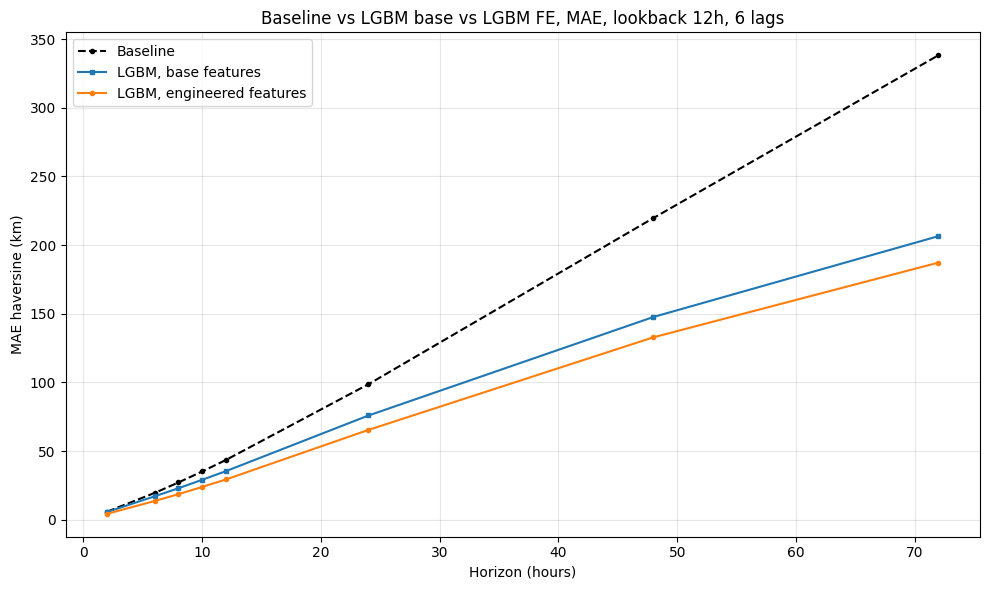

In [49]:
def plot_metric_vs_horizon(metric, ylabel, title):
    """Plot one metric against horizon for baseline, base features and FE features.

    Parameters
    ----------
    metric : str
        Column of summary_fe to plot, "mae_mean" or "r90_km".
    ylabel : str
        Y axis label.
    title : str
        Plot title.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    series = [
        ("baseline", "Baseline", {"color": "black", "marker": "o", "linestyle": "--"}),
        ("base", "LGBM, base features", {"color": "C0", "marker": "s", "linestyle": "-"}),
        ("fe", "LGBM, engineered features", {"color": "C1", "marker": "o", "linestyle": "-"}),
    ]
    for feature_set, label, style in series:
        subset = summary_fe[summary_fe["feature_set"] == feature_set].sort_values("horizon_hours")
        ax.plot(subset["horizon_hours"], subset[metric], markersize=3, label=label, **style)

    ax.set_xlabel("Horizon (hours)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric_vs_horizon(
    "mae_mean",
    "MAE haversine (km)",
    f"Baseline vs LGBM base vs LGBM FE, MAE, lookback {lookback}h, {nb_lags} lags",
)


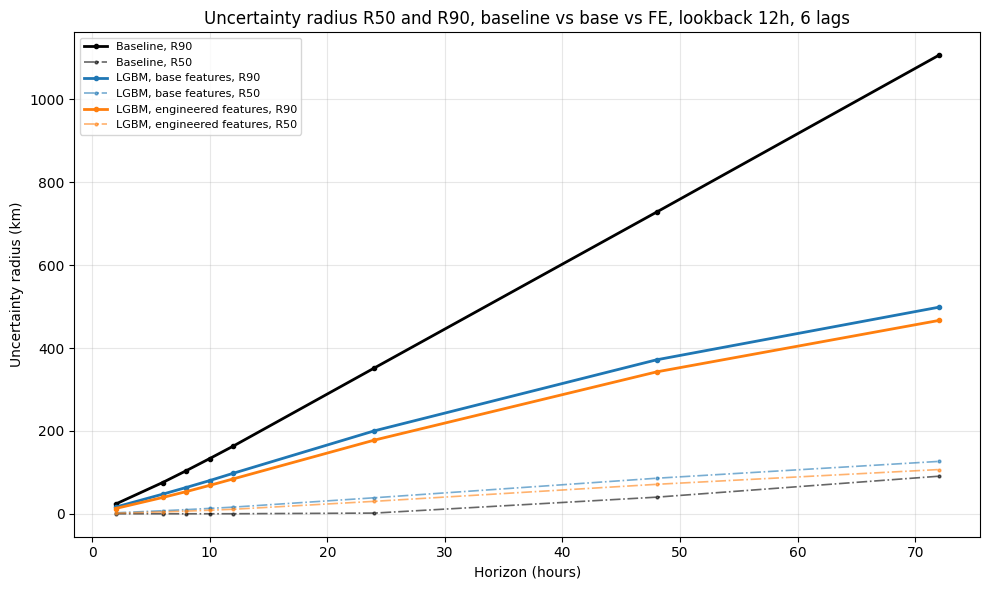

In [50]:
# Radius plot, R90 and R50 together. R90 sizes the search area, R50 shows whether
# the engineered features also help on the easy half of the cases.
fig, ax = plt.subplots(figsize=(10, 6))
for feature_set, label, color in [
    ("baseline", "Baseline", "black"),
    ("base", "LGBM, base features", "C0"),
    ("fe", "LGBM, engineered features", "C1"),
]:
    subset = summary_fe[summary_fe["feature_set"] == feature_set].sort_values("horizon_hours")
    ax.plot(subset["horizon_hours"], subset["r90_km"], color=color, linestyle="-",
            linewidth=2.0, marker="o", markersize=3, label=f"{label}, R90")
    ax.plot(subset["horizon_hours"], subset["r50_km"], color=color, linestyle="-.",
            linewidth=1.2, alpha=0.6, marker="o", markersize=2, label=f"{label}, R50")

ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("Uncertainty radius (km)")
ax.set_title(f"Uncertainty radius R50 and R90, baseline vs base vs FE, lookback {lookback}h, {nb_lags} lags")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

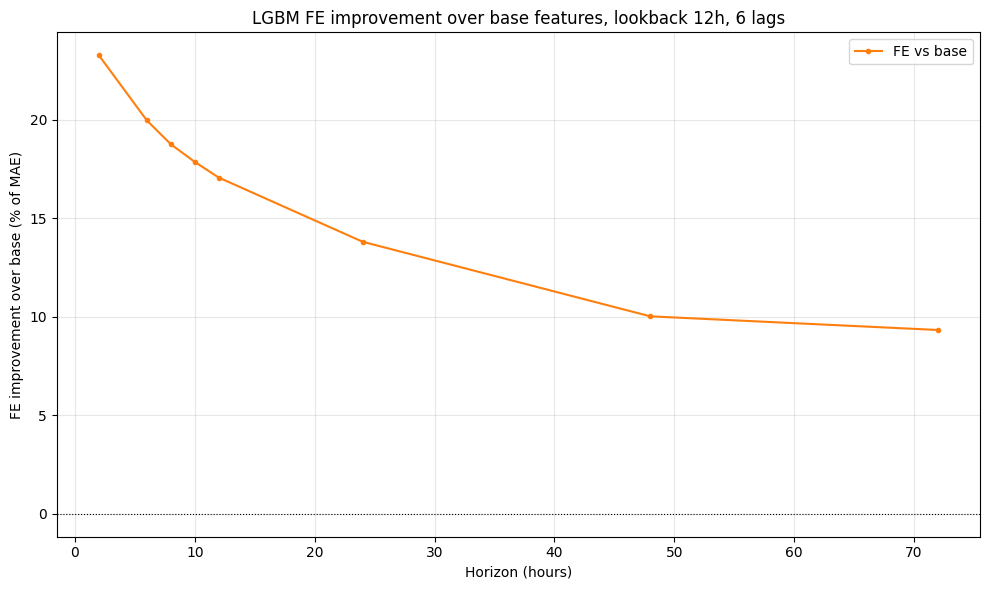

In [51]:
# --- Plot 3: FE improvement over base, percent of MAE ---
base_lookup = (
    summary_fe[summary_fe["feature_set"] == "base"]
    .set_index("horizon_hours")["mae_mean"]
)
fe_df = summary_fe[summary_fe["feature_set"] == "fe"].sort_values("horizon_hours")
mae_base = fe_df["horizon_hours"].map(base_lookup)
improvement_pct = (mae_base - fe_df["mae_mean"]) / mae_base * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fe_df["horizon_hours"], improvement_pct, marker="o", markersize=3,
        linestyle="-", color="C1", label="FE vs base")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("FE improvement over base (% of MAE)")
ax.set_title(f"LGBM FE improvement over base features, lookback {lookback}h, {nb_lags} lags")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3.4 Conclusion, Feature Engineering

- Engineered features cut MAE by 9 to 23 percent depending on horizon: 23 percent at 2h, 17 at 12h, 14 at 24h, 9 at 72h. That is several times the ~2.4 percent hyperparameter tuning gave in NB05, which points to an informational ceiling rather than a tuning problem.
- Relative MAE gain shrinks with horizon; absolute MAE gain grows (1.3 km at 2h, 19 km at 72h). The same pattern holds for the R90 search disk (`area = π R90²`): a 21 percent radius cut at 2h is a 37 percent area cut (305 km²), while at 72h a 6 percent radius cut is still a 12 percent area cut (~97 000 km²). Absolute area saved grows with horizon even as the relative cut shrinks.
- No horizon flips across the 10 NM operational reference because of these features. At 2h, R90 goes from 16.1 km to 12.7 km — both already inside 10 NM (18.5 km). At 72h it goes from 499 km to 467 km — both far outside any usable search box. The features tighten the zone without changing what an operator can do with it.
- The gain is not confined to one part of the error distribution. At 72h, base→fe cuts 19.7 km at R50, 37.8 at R80, 32.0 at R90 and 30.9 at R95.


## 4. Feature selection


Objectives: check whether removing dead features improves performance, produce a leaner set with equivalent performance, and understand what each feature group contributes at the model level.

The order is correlation first, to know which features move together and therefore which ablation results have to be read as a pair, then leave-one-group-out ablation for ranking, then a comparison of candidate sets for the decision.


### 4.1 Correlation between features

Two features carrying the same information will each look dispensable when dropped alone, since the other one covers for it. So we take a look at correlation pairs. Hierarchical clustering was left aside for saving time even though it could informs groups of correlated featuers. 

Position lags are excluded here. Their mutual correlation is trivial, a trajectory is autocorrelated by construction, and their correlation with motion or dimension features encodes geography (vessels in one area are slower than in another) rather than feature redundancy.


In [52]:
# Spearman between non-position features. 

corr_feature_cols = [
    c for c in fe_cols
    if not c.startswith(("LAT_lag", "LON_lag")) and c != "h"
]
corr_reference_h = min(df_long["h"]) #we'll do the correlation at min horizon
print(f"corr features ({len(corr_feature_cols)}): {corr_feature_cols}")
print(f"reference horizon: {corr_reference_h // 60}h")

corr = df_long[df_long["h"] == corr_reference_h][corr_feature_cols].corr(method="spearman")

mask = np.triu(np.ones(corr.shape, dtype=bool))
pairs_corr = (
    corr.mask(mask) #mask the upper triangle
    .stack() #series multiindex feature i feature j
    .rename("spearman")
    .reset_index()
    .rename(columns={"level_0": "f1", "level_1": "f2"})
)
pairs_corr["abs_spearman"] = pairs_corr["spearman"].abs()
pairs_corr = pairs_corr.sort_values("abs_spearman", ascending=False).reset_index(drop=True)
display(pairs_corr.head(15).round(3))




corr features (12): ['SOG', 'Heading_sin', 'Heading_cos', 'Length', 'Width', 'Draft', 'dx', 'dy', 'curvature_rate', 'effective_speed_knots', 'speed_trend_knots', 'recent_turn_rate']
reference horizon: 2h


,f1,f2,spearman,abs_spearman
0,Width,Length,0.925,0.925
1,Draft,Length,0.728,0.728
2,Draft,Width,0.728,0.728
3,speed_trend_knots,SOG,0.700,0.700
4,speed_trend_knots,curvature_rate,-0.633,0.633
5,curvature_rate,SOG,-0.631,0.631
6,dx,Heading_sin,0.422,0.422
7,dy,Heading_cos,0.372,0.372
8,Draft,SOG,0.340,0.340
9,Length,SOG,0.319,0.319


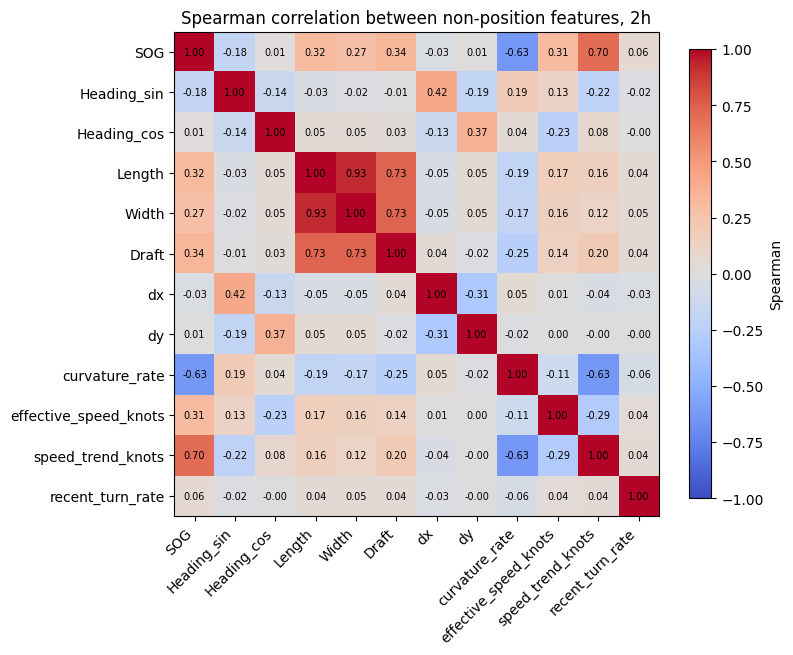

In [53]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_feature_cols)))
ax.set_xticklabels(corr_feature_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_feature_cols)))
ax.set_yticklabels(corr_feature_cols)
for i in range(len(corr_feature_cols)):
    for j in range(len(corr_feature_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman")
ax.set_title(f"Spearman correlation between non-position features, {corr_reference_h // 60}h")
plt.tight_layout()
plt.show()


Overall no strong correlation (say, above 0.8) excepted for geometry. 
The geometry features form the only tight cluster: `Width` with `Length` at 0.93, `Draft` with each of them at 0.73. Larger vessels are larger in every dimension. So we'll remove them as one single group during the ablation phase. 

 `SOG` and `speed_trend_knots` and present a lower correlation (0.70) explained by construction, `speed_trend_knots` is `SOG` minus the effective speed (average speed over timesteps of the lookback window). 

The negative link with `curvature_rate` probably comes from stationary vessels, where GPS jitter around a fixed point produces a large apparent turn rate at near zero speed. 

`dx` show a limited correlation with `Heading_sin` (0.42),  and `dy` with `Heading_cos` (0.37), which is expected since a moving vessel points roughly where it goes. 

### 4.2 Ablation

Leave-one-group-out. The model is retrained with one feature group removed at a time, on the same rows and the same folds as the full set. A positive degradation means the model is worse without that group.

Correlated features hide each other under this protocol. If two features carry the same signal, removing either one alone costs little and both look dispensable. The ablation ranks features. Deciding which set to keep is what 4.4 does.

Four probe horizons (2h, 12h, 24h, 72h) are used instead of the full grid, since what matters here is the shape of the effect across the range.


In [54]:
ablation_groups = {
    "full": [],
    "dx": ["dx"],
    "dy": ["dy"],
    "curvature_rate": ["curvature_rate"],
    "effective_speed": ["effective_speed_knots"],
    "speed_trend": ["speed_trend_knots"],
    "recent_turn_rate": ["recent_turn_rate"],
    "heading": ["Heading_sin", "Heading_cos"],
    "SOG": ["SOG"],
    "geometry": ["Length", "Width", "Draft"],
}
probe_horizons_hours = [2, 12, 24, 72]

FORCE_RECOMPUTE = True  # set True to refit even if cached output exists
out_dir = Path("outputs")
ablation_path = out_dir / "lgbm_ablation_12h.csv"

if not FORCE_RECOMPUTE and ablation_path.exists():
    print("Cached ablation summary found, loading from disk (set FORCE_RECOMPUTE=True to refit).")
    results_ablation = pd.read_csv(ablation_path)
else:
    lgbm_model_ablation = LGBMRegressor(verbose=-1, random_state=settings.random_seed)

    ablation_rows = []
    for group_name, dropped in ablation_groups.items():
        cols = [c for c in fe_cols if c not in dropped]
        print(f"CV ablated={group_name!r} | n_features={len(cols)} ...")
        oof, _ = run_crossval(
            df=df_long, model=lgbm_model_ablation, model_name="lgbm",
            lookback_minutes=lookback * 60, feature_cols=cols, with_baseline=False,
        )
        m = compute_metrics(oof)
        m["ablated_group"] = group_name
        ablation_rows.append(m)
        del oof
        gc.collect()

    results_ablation = pd.concat(ablation_rows, ignore_index=True)
    results_ablation["horizon_hours"] = (results_ablation["h"] / 60).round().astype(int)
    results_ablation = results_ablation[results_ablation["horizon_hours"].isin(probe_horizons_hours)]
    results_ablation.to_csv(ablation_path, index=False)

results_ablation


CV ablated='full' | n_features=25 ...
CV ablated='dx' | n_features=24 ...
CV ablated='dy' | n_features=24 ...
CV ablated='curvature_rate' | n_features=24 ...
CV ablated='effective_speed' | n_features=24 ...
CV ablated='speed_trend' | n_features=24 ...
CV ablated='recent_turn_rate' | n_features=24 ...
CV ablated='heading' | n_features=23 ...
CV ablated='SOG' | n_features=24 ...
CV ablated='geometry' | n_features=22 ...


,model_name,h,mae_mean,r50_km,r80_km,r90_km,r95_km,ablated_group,horizon_hours
0,lgbm,120,4.386931,1.426719,6.471842,12.744399,19.183832,full,2
4,lgbm,720,29.396011,10.885342,44.133515,84.194532,126.529412,full,12
5,lgbm,1440,65.457536,30.098742,100.778190,177.820999,257.312116,full,24
7,lgbm,4320,187.236440,106.804605,285.816280,466.643333,641.648221,full,72
8,lgbm,120,4.716430,1.783993,7.135118,13.240329,19.657634,dx,2
12,lgbm,720,31.253680,12.990338,47.066360,87.536205,129.595536,dx,12
13,lgbm,1440,68.737572,34.151676,105.479315,183.290493,260.868304,dx,24
15,lgbm,4320,193.693942,113.374270,297.293574,477.982121,650.367860,dx,72
16,lgbm,120,4.633896,1.698888,6.854054,13.242944,19.738415,dy,2
20,lgbm,720,30.634740,12.215751,45.674963,86.087782,128.684707,dy,12


In [55]:
full_ref = results_ablation[results_ablation["ablated_group"] == "full"].set_index("horizon_hours")


def degradation_vs_full(metric):
    """Metric increase caused by removing each feature group, against the full set.

    Parameters
    ----------
    metric : str
        Column of results_ablation to compare, "mae_mean" or "r90_km".

    Returns
    -------
    DataFrame
        Index = ablated group, columns = probe horizons, values in km.
        Positive means the model is worse without that group.
    """
    tbl = (
        results_ablation[results_ablation["ablated_group"] != "full"]
        .pivot_table(index="ablated_group", columns="horizon_hours", values=metric)
    )
    return (tbl - full_ref[metric]).round(2)


mae_degradation = degradation_vs_full("mae_mean")
r90_degradation = degradation_vs_full("r90_km")

print("MAE degradation vs full (km), positive = worse without the group:")
display(mae_degradation)
print("R90 degradation vs full (km), positive = worse without the group:")
display(r90_degradation)


MAE degradation vs full (km), positive = worse without the group:


horizon_hours,2,12,24,72
ablated_group,,,,
SOG,0.08,0.11,-0.06,-0.22
curvature_rate,0.04,0.30,0.08,0.12
dx,0.33,1.86,3.28,6.46
dy,0.25,1.24,2.16,4.40
effective_speed,-0.02,-0.08,-0.28,-1.06
geometry,-0.11,-0.29,0.22,3.69
heading,0.30,0.12,-0.14,-1.47
recent_turn_rate,0.05,0.05,-0.12,-0.44
speed_trend,-0.02,-0.06,-0.33,-1.22


R90 degradation vs full (km), positive = worse without the group:


horizon_hours,2,12,24,72
ablated_group,,,,
SOG,0.33,0.43,0.18,-1.25
curvature_rate,-0.05,0.01,0.07,-3.11
dx,0.50,3.34,5.47,11.34
dy,0.50,1.89,2.89,2.69
effective_speed,-0.07,-0.33,-0.31,-1.13
geometry,-0.20,-0.26,3.20,9.39
heading,1.35,1.15,0.32,-1.24
recent_turn_rate,0.09,-0.09,-0.15,-0.27
speed_trend,-0.08,-0.10,0.37,-1.25


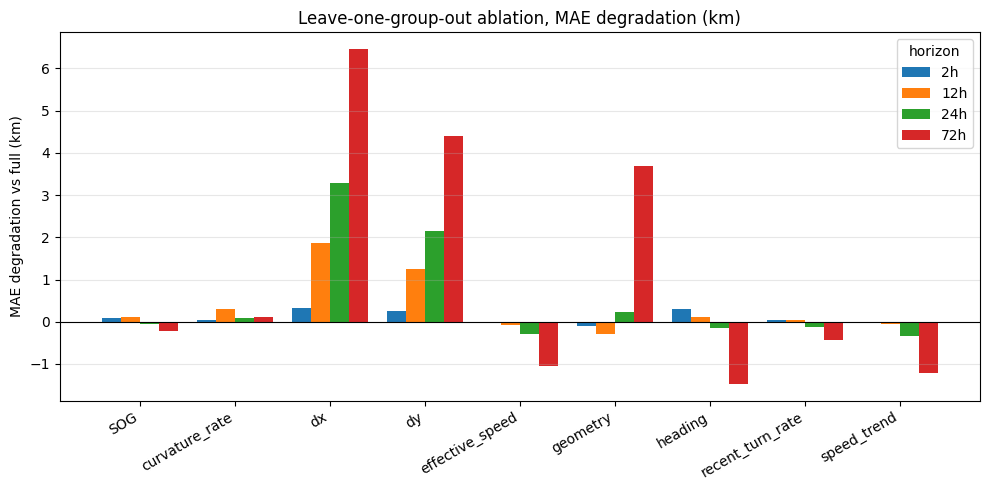

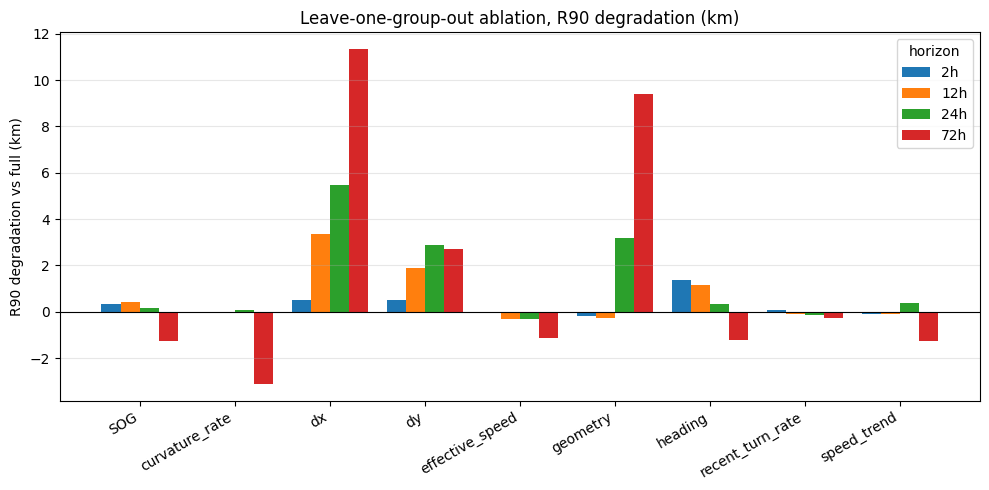

In [56]:
def plot_degradation(degradation_tbl, ylabel, title):
    """Grouped bar chart of ablation degradation, one bar group per feature group.

    Parameters
    ----------
    degradation_tbl : DataFrame
        Output of degradation_vs_full. Index = ablated group, columns = horizons.
    ylabel : str
        Y axis label.
    title : str
        Plot title.
    """
    groups = list(degradation_tbl.index)
    horizons_plot = list(degradation_tbl.columns)
    x = np.arange(len(groups))
    width = min(0.8 / len(horizons_plot), 0.25)

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, h in enumerate(horizons_plot):
        offset = (i - (len(horizons_plot) - 1) / 2) * width
        ax.bar(x + offset, degradation_tbl[h].to_numpy(), width, label=f"{h}h")

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title="horizon")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_degradation(
    mae_degradation,
    "MAE degradation vs full (km)",
    "Leave-one-group-out ablation, MAE degradation (km)",
)
plot_degradation(
    r90_degradation,
    "R90 degradation vs full (km)",
    "Leave-one-group-out ablation, R90 degradation (km)",
)


### 4.3 Interpretation

**`dx` and `dy` dominate.** They are the only groups whose removal consistently reduce performance: 6.5 and 4.4 km of MAE at 72h, 11.3 and 2.7 km of R90. 

That alone does not explain why `dx` and `dy` work while `curvature_rate`, `speed_trend_knots` and `recent_turn_rate`, which are also re-representations of the same trajectory, do not. The target is the mean future velocity, and the lookback displacement is the mean past velocity, the closest available statistic to the form of the target. 

This is not to say that they are sufficient, otherwise the baseline model would be enough. The others features describe second order quantities (curvature, acceleration) that only matter when the future departs from constant velocity, which is the minority of cases and the noisiest part of the data.

**Geometry matters only at long horizons.** `Length`, `Width` and `Draft` say nothing about current motion, consistent with their null or slightly negative contribution at 2h and 12h. At 72h removing them costs 3.7 km of MAE and 9.4 km of R90. We can suppose that, at that range position is governed by destination rather than kinematics, and that vessel size predicts destination:.

**Local dynamics features turn negative at long horizons.** Five groups show negative degradation at 72h, meaning the model does better without them: `heading` (-1.5 km MAE), `speed_trend` (-1.2), `effective_speed` (-1.1), `recent_turn_rate` (-0.4), `SOG` (-0.2). These are exactly the features describing what the vessel is doing right now.

We should note though that these magnitudes are small, under 1 percent of the MAE at that horizon, and no error bars were computed. Taken individually none of them is very significant.  

Surprisingly, `recent_turn_rate` and `speed_trend_knots` contribute nothing at any horizon, including the short ones where local dynamics should matter most (0.05 and -0.02 km of MAE at 2h). 

**Leave-one-out understates the total.** The engineered features altogether improved the MAE by 19.3 km at 72h (206.5 against 187.2). The individual contributions listed here sum to roughly 10 km, but that sum mixes engineered groups with base feature groups (geometry, heading, SOG). This is probably due to a certain redundancy between the added features. 


### 4.4 Feature-set comparison

Objectives: 
- check whether the intermediate position lags still carry anything once the displacement is explicit in dx and dy (3 against 4).
- check weather the heading features is useful (it show a mix pattern of positive and negative contribution) on a smaller feature sets (less risks of redundancy)
- check whether we can find a smaller, leaner features set that retains most of the model performance. 

| # | Set | Features |
|---|-----|----------|
| 1 | `base` | all LAT/LON lags + SOG + Heading sin/cos + geometry |
| 2 | `fe` | base + dx, dy, curvature_rate, effective_speed_knots, speed_trend_knots, recent_turn_rate |
| 3 | `lags_dxdy_geom` | all LAT/LON lags + dx, dy + geometry |
| 4 | `lag0_dxdy_geom` | LAT_lag_0, LON_lag_0 + dx, dy + geometry |
| 5 | `lag0_dxdy_geom_heading` | (4) + Heading_sin, Heading_cos |


In [57]:
# Reduced feature sets. base and fe come from section 3.3 and are reused, only the
# reduced sets are run here. Named selection_sets to avoid colliding with the
# feature_sets dict used in section 3.3.
geom_cols = ["Length", "Width", "Draft"]

selection_sets = {
    "lags_dxdy_geom": lag_cols + ["dx", "dy"] + geom_cols,
    "lag0_dxdy_geom": ["LAT_lag_0", "LON_lag_0", "dx", "dy"] + geom_cols,
    "lag0_dxdy_geom_heading": ["LAT_lag_0", "LON_lag_0", "dx", "dy", "Heading_sin", "Heading_cos"] + geom_cols,
}
for name, cols in selection_sets.items():
    print(f"{name} ({len(cols)}): {cols}")

FORCE_RECOMPUTE = False  # set True to refit even if cached output exists
out_dir = Path("outputs")
selection_path = out_dir / "lgbm_feature_sets_12h.csv"

if not FORCE_RECOMPUTE and selection_path.exists():
    print("Cached feature-set summary found, loading from disk (set FORCE_RECOMPUTE=True to refit).")
    summary_selection = pd.read_csv(selection_path)
else:
    lgbm_model_selection = LGBMRegressor(verbose=-1, random_state=settings.random_seed)

    selection_parts = []
    for name, cols in selection_sets.items():
        print(f"CV [{name}] ...")
        oof, _ = run_crossval(
            df=df_long, model=lgbm_model_selection, model_name="lgbm",
            lookback_minutes=lookback * 60, feature_cols=cols, with_baseline=False,
        )
        m = compute_metrics(oof)
        m["feature_set"] = name
        selection_parts.append(m)
        del oof
        gc.collect()

    summary_selection = pd.concat([summary_fe] + selection_parts, ignore_index=True)
    summary_selection["horizon_hours"] = (summary_selection["h"] / 60).round().astype(int)
    summary_selection.to_csv(selection_path, index=False)

print(f"feature sets compared: {sorted(summary_selection['feature_set'].unique())}")


lags_dxdy_geom (17): ['LAT_lag_0', 'LON_lag_0', 'LAT_lag_14', 'LON_lag_14', 'LAT_lag_29', 'LON_lag_29', 'LAT_lag_43', 'LON_lag_43', 'LAT_lag_58', 'LON_lag_58', 'LAT_lag_72', 'LON_lag_72', 'dx', 'dy', 'Length', 'Width', 'Draft']
lag0_dxdy_geom (7): ['LAT_lag_0', 'LON_lag_0', 'dx', 'dy', 'Length', 'Width', 'Draft']
lag0_dxdy_geom_heading (9): ['LAT_lag_0', 'LON_lag_0', 'dx', 'dy', 'Heading_sin', 'Heading_cos', 'Length', 'Width', 'Draft']
Cached feature-set summary found, loading from disk (set FORCE_RECOMPUTE=True to refit).
feature sets compared: ['base', 'baseline', 'fe', 'lag0_dxdy_geom', 'lag0_dxdy_geom_heading', 'lags_dxdy_geom']


In [58]:
summary_selection

,model_name,h,mae_mean,r50_km,r80_km,r90_km,r95_km,feature_set,horizon_hours
0,lgbm,120,5.717384,2.397911,9.490821,16.110362,22.505396,base,2
1,lgbm,360,17.125715,7.400179,28.159134,47.355379,67.297883,base,6
2,lgbm,480,22.993104,10.090219,37.431037,63.445130,90.687376,base,8
3,lgbm,600,29.147155,13.020308,47.040694,80.186318,114.623220,base,10
4,lgbm,720,35.443629,16.093223,57.229390,97.748529,138.386156,base,12
5,lgbm,1440,75.941914,38.687139,124.958743,200.208387,274.285897,base,24
6,lgbm,2880,147.663695,85.836557,234.421249,371.681602,495.017387,base,48
7,lgbm,4320,206.497788,126.471707,323.607996,498.629543,672.509261,base,72
8,Baseline,120,5.946098,0.005674,10.551022,23.414790,32.769911,baseline,2
9,Baseline,360,19.591216,0.024939,37.916783,75.457968,101.417324,baseline,6


In [59]:
set_order = ["baseline", "base", "fe", "lags_dxdy_geom", "lag0_dxdy_geom", "lag0_dxdy_geom_heading"]
reduced_sets = ["lags_dxdy_geom", "lag0_dxdy_geom", "lag0_dxdy_geom_heading"]


def pivot_selection(metric):
    """Lay out one metric as one row per horizon and one column per feature set.

    Parameters
    ----------
    metric : str
        Column of summary_selection to pivot, for example "mae_mean" or "r90_km".

    Returns
    -------
    DataFrame
        Index = horizon in hours, columns = the feature sets in set_order.
    """
    return (
        summary_selection.pivot_table(index="horizon_hours", columns="feature_set", values=metric)
        .reindex(columns=set_order)
        .sort_index()
    )


mae_sets = pivot_selection("mae_mean").round(2)
r90_sets = pivot_selection("r90_km").round(2)

print("MAE (km) by feature set:")
display(mae_sets)
print("R90 (km) by feature set:")
display(r90_sets)

# Share of the full FE gain each reduced set retains. 100 means it matches the full
# engineered set, 0 means it falls back to the base features.
fe_gain_kept = (
    (mae_sets["base"].values[:, None] - mae_sets[reduced_sets])
    .div(mae_sets["base"] - mae_sets["fe"], axis=0) * 100
).round(1)

print("Share of the FE MAE gain kept by each reduced set (%):")
display(fe_gain_kept)

MAE (km) by feature set:


feature_set,baseline,base,fe,lags_dxdy_geom,lag0_dxdy_geom,lag0_dxdy_geom_heading
horizon_hours,,,,,,
2,5.95,5.72,4.39,5.02,5.30,5.02
6,19.59,17.13,13.71,14.88,15.50,15.09
8,27.19,22.99,18.68,19.99,20.69,20.33
10,35.21,29.15,23.94,25.30,26.08,25.75
12,43.59,35.44,29.40,30.80,31.67,31.44
24,98.71,75.94,65.46,66.59,67.21,67.52
48,219.71,147.66,132.87,133.04,134.17,135.40
72,338.18,206.50,187.24,187.93,188.66,190.96


R90 (km) by feature set:


feature_set,baseline,base,fe,lags_dxdy_geom,lag0_dxdy_geom,lag0_dxdy_geom_heading
horizon_hours,,,,,,
2,23.41,16.11,12.74,15.04,16.09,14.63
6,75.46,47.36,39.34,42.78,45.09,43.34
8,103.89,63.45,53.51,57.03,59.82,58.24
10,133.26,80.19,68.55,71.88,74.75,73.67
12,163.28,97.75,84.19,87.16,90.35,89.40
24,351.89,200.21,177.82,178.90,181.15,180.62
48,728.15,371.68,342.51,339.92,342.50,343.27
72,1106.72,498.63,466.64,464.91,464.97,465.94


Share of the FE MAE gain kept by each reduced set (%):


feature_set,lags_dxdy_geom,lag0_dxdy_geom,lag0_dxdy_geom_heading
horizon_hours,,,
2,52.6,31.6,52.6
6,65.8,47.7,59.6
8,69.6,53.4,61.7
10,73.9,58.9,65.3
12,76.8,62.4,66.2
24,89.2,83.3,80.3
48,98.9,91.2,82.9
72,96.4,92.6,80.7


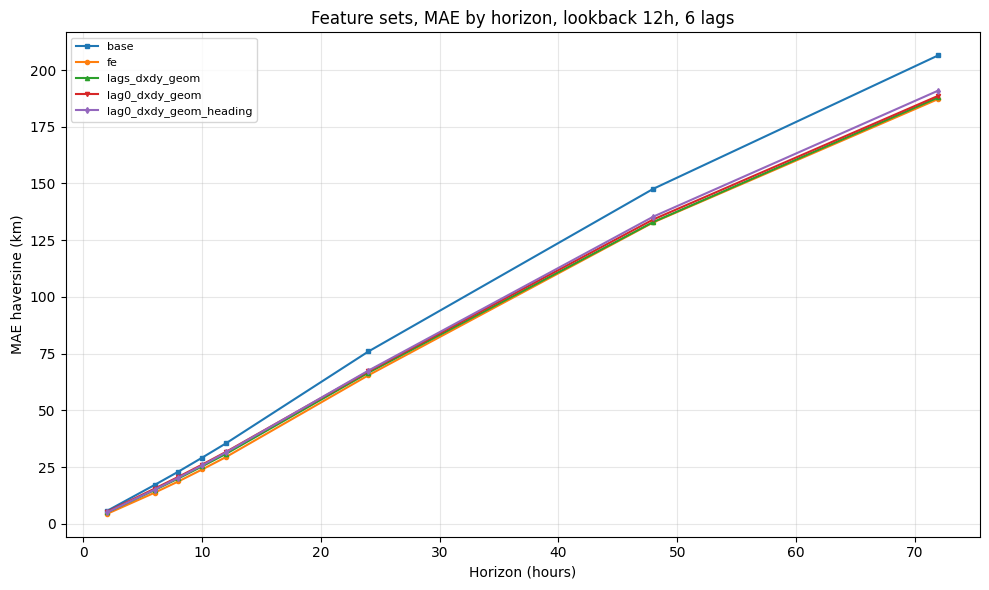

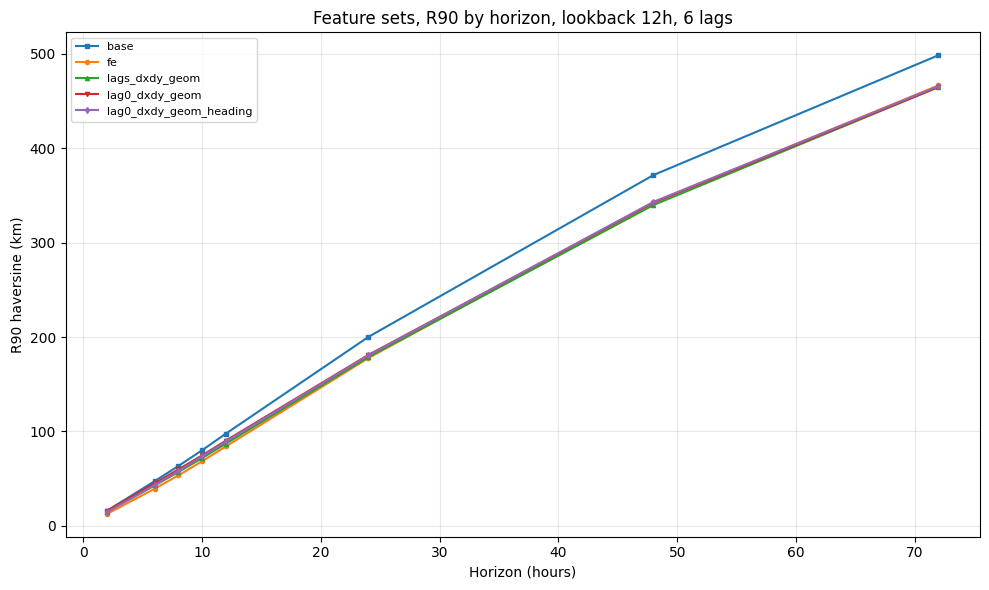

In [60]:
# The baseline is left out of these curves on purpose. Its error is far above every
# model set (338 km against 187 to 206 km at 72h), which would compress the scale and
# hide the differences between sets. The baseline comparison is in section 3.3.
plotted_sets = ["base", "fe", "lags_dxdy_geom", "lag0_dxdy_geom", "lag0_dxdy_geom_heading"]
set_styles = {
    "base": {"color": "C0", "marker": "s"},
    "fe": {"color": "C1", "marker": "o"},
    "lags_dxdy_geom": {"color": "C2", "marker": "^"},
    "lag0_dxdy_geom": {"color": "C3", "marker": "v"},
    "lag0_dxdy_geom_heading": {"color": "C4", "marker": "d"},
}


def plot_sets_vs_horizon(metric, ylabel, title):
    """Plot one metric against horizon, one line per feature set.

    Parameters
    ----------
    metric : str
        Column of summary_selection to plot, for example "mae_mean" or "r90_km".
    ylabel : str
        Y axis label.
    title : str
        Plot title.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    for feature_set in plotted_sets:
        subset = (
            summary_selection[summary_selection["feature_set"] == feature_set]
            .sort_values("horizon_hours")
        )
        ax.plot(subset["horizon_hours"], subset[metric], linestyle="-", markersize=3,
                label=feature_set, **set_styles[feature_set])
    ax.set_xlabel("Horizon (hours)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_sets_vs_horizon(
    "mae_mean",
    "MAE haversine (km)",
    f"Feature sets, MAE by horizon, lookback {lookback}h, {nb_lags} lags",
)
plot_sets_vs_horizon(
    "r90_km",
    "R90 haversine (km)",
    f"Feature sets, R90 by horizon, lookback {lookback}h, {nb_lags} lags",
)

### 4.5 Conclusion, Feature Selection

**Retained set: all LAT/LON lags, `dx`, `dy`, `Length`, `Width`, `Draft`.**

- **At 48–72h**, the four non-base sets are within ~2 km of R90 of each other, so the choice barely matters there.
- **At 2h**, leanest set, `lag0_dxdy_geom` (2 positions only), falls back near `base` (16.1 km R90 vs 12.7 for `fe`). Keeping the intermediate lags instead of just lag0 recovers part of that gap (about a third, 16.09 to 15.04 km R90 at 2h) at negligible cost, since those lags are already computed. Therefore, we'll chose `lags_dxdy_geom` over the leaner variant.
- **Heading** gives a small short-horizon R90 gain in the lean set (16.09 to 14.63 km at 2h) and turns slightly negative at 72h. The leave-one-out ablation on the full set also ranked it net negative at 24h and 72h. Intermediate lags already recover part of the short-horizon signal, so Heading is not kept.


## 5. Conclusion

**Retained feature set:** all LAT/LON lags (6 lags over a 12h lookback), `dx`, `dy`, `Length`, `Width`, `Draft`, plus `h`.

**Feature engineering gives more than tuning.** Engineered features cut MAE by 9 to 23 percent depending on horizon, several times what hyperparameter tuning gave in NB05. Nearly all of it comes from `dx` and `dy`. These represent the lookback displacement, the same quantity the deterministic baseline extrapolates. Handing it to the model explicitly is more efficient than making the model reconstruct it from raw lags.

**Local-dynamics descriptors do not help.** Curvature, effective speed, speed trend and recent turn rate contribute nothing measurable at any horizon, and turn negative at 72h. 
